# Practice Assignment 2

In this assignment, you will explore the Online Shoppers Purchasing Intention Dataset to build a machine learning model that predicts whether a visitor will make a purchase. you will analyze data in the online_shoppers_intention.csv file.You'll use functions from the pandas module for loading, inspecting and querying the data. You are expected to preprocess the data and use the data to train machine learning models from the sklearn library to solve problems.

The useful dataset link: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

For each question, there are clear instructions in each cell. Follow those instructions and write the code after each block of:

YOUR CODE HERE

Please use the exact variable name if it is specified in the comment.

We’ll run a Python test script against your program to test whether each function implementation is correct.

In [1]:
%%capture
###########################################################
### EXECUTE THIS CELL BEFORE YOU TO TEST YOUR SOLUTIONS ###
###########################################################
"""
Import all libraries needed for the entire exercise: numpy, pyplot, and seaborn
"""
import imp
import numpy as np
from nose.tools import assert_equal
from pandas.util.testing import assert_frame_equal, assert_series_equal
sol = imp.load_compiled("sol", "./.sol.py")

In [2]:
"""
Part 01: Setup and Data Loading

1. Import the pandas library.

2. Use pandas to read the dataset from the .csv file and save it to "shoppers_df". 

3. In certain datasets, a value of 0 (zero) can indicate missing information that was not recorded. 
   In the case of our dataset, assume that 0's represent missing data for the following analysis.
   
   Replace all 0 or 0.0 values in the DataFrame with NaN using replace(). 
   Hint: Make sure to set inplace to True.

3. Display the first 5 rows of the DataFrame "shoppers_df".

"""

# YOUR CODE HERE

import pandas as pd
import numpy as np

# 1. & 2. Load the dataset from the CSV file
shoppers_df = pd.read_csv('online_shoppers_intention.csv')

# 3. Replace all 0 or 0.0 values with NaN
# We use np.nan from the numpy library to represent the missing values
shoppers_df.replace(0, np.nan, inplace=True)
shoppers_df.replace(0.0, np.nan, inplace=True)

# 4. Display the first 5 rows
print(shoppers_df.head())

   Administrative  Administrative_Duration  Informational  \
0             NaN                      NaN            NaN   
1             NaN                      NaN            NaN   
2             NaN                      NaN            NaN   
3             NaN                      NaN            NaN   
4             NaN                      NaN            NaN   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     NaN             1.0                      NaN   
1                     NaN             2.0                64.000000   
2                     NaN             1.0                      NaN   
3                     NaN             2.0                 2.666667   
4                     NaN            10.0               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         NaN         NaN   Feb                 1   
1          NaN       0.10         NaN         NaN   Feb   

In [4]:
##########################
### TEST YOUR SOLUTION ###
##########################

assert_frame_equal(shoppers_df, sol.shoppers_df)


In [5]:
"""
Part 02: Data Exploration

1. Display the shape of the DataFrame "shoppers_df" to know the number of rows and columns. 
   Store the shape in a variable called "shape_of_df"

2. Use the `info()` method on "shoppers_df" to display the summary including the data types 
   and the presence of null values.

3. Create a variable named "missing_values_count" that stores the total count of missing 
   values in the DataFrame.
"""

# YOUR CODE HERE

# 1. Store the shape of the DataFrame
shape_of_df = shoppers_df.shape
print(f"The DataFrame has {shape_of_df[0]} rows and {shape_of_df[1]} columns.\n")

# 2. Display the summary including data types and null counts
print("Summary Information:")
shoppers_df.info()

# 3. Store the total count of missing values in the DataFrame
missing_values_count = shoppers_df.isnull().sum().sum()
print(f"\nTotal count of missing values: {missing_values_count}")


The DataFrame has 12330 rows and 18 columns.

Summary Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           6562 non-null   float64
 1   Administrative_Duration  6427 non-null   float64
 2   Informational            2631 non-null   float64
 3   Informational_Duration   2405 non-null   float64
 4   ProductRelated           12292 non-null  float64
 5   ProductRelated_Duration  11575 non-null  float64
 6   BounceRates              6812 non-null   float64
 7   ExitRates                12254 non-null  float64
 8   PageValues               2730 non-null   float64
 9   SpecialDay               1251 non-null   float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region   

In [6]:
##########################
### TEST YOUR SOLUTION ###
##########################

assert_equal(shape_of_df, sol.shape_of_df)


In [7]:
"""
Part 03: Data Pre-processing

1. First save old df to "new_shoppers_df"

2. Inspect the dataset for missing values in each column and handle them appropriately. 
   For each column, fill any missing values with the mode of that column. Implement this using a for loop.

3. Drop the 'Month' column from "new_shoppers_df" as it will not be used in further analysis.

4. Perform one-hot encoding on the 'VisitorType' column. 
  
  First, use `pd.get_dummies()` to create a DataFrame "visitor_dummies". 
  
  Then, concatenate "visitor_dummies" with "shoppers_df"
  
  a. Hint: For more about pd.get_dummies(): 
       https://www.geeksforgeeks.org/python-pandas-get_dummies-method/
  b. Do not forget to drop the old 'VisitorType' column
  c. Set parameter drop_first = True. We only need k-1 catergoies to represent
     k catergorical values. 

5. After the encoding and concatenation, display the first 5 rows of "new_shoppers_df" to verify the changes.
  
"""

# YOUR CODE HERE

# 1. Save old df to "new_shoppers_df"
new_shoppers_df = shoppers_df.copy()

# 2. Fill missing values with the mode using a for loop
for col in new_shoppers_df.columns:
    # mode() returns a Series, so we take index [0] to get the value
    column_mode = new_shoppers_df[col].mode()[0]
    new_shoppers_df[col] = new_shoppers_df[col].fillna(column_mode)

# 3. Drop the 'Month' column
new_shoppers_df.drop(columns=['Month'], inplace=True)

# 4. Perform one-hot encoding on 'VisitorType'
# Using drop_first=True helps avoid the "dummy variable trap" (multicollinearity)
visitor_dummies = pd.get_dummies(new_shoppers_df['VisitorType'], drop_first=True)

# Concatenate dummies and drop the original 'VisitorType' column
new_shoppers_df = pd.concat([new_shoppers_df, visitor_dummies], axis=1)
new_shoppers_df.drop(columns=['VisitorType'], inplace=True)

# 5. Verify the changes
print(new_shoppers_df.head())

   Administrative  Administrative_Duration  Informational  \
0             1.0                      4.0            1.0   
1             1.0                      4.0            1.0   
2             1.0                      4.0            1.0   
3             1.0                      4.0            1.0   
4             1.0                      4.0            1.0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     9.0             1.0                17.000000   
1                     9.0             2.0                64.000000   
2                     9.0             1.0                17.000000   
3                     9.0             2.0                 2.666667   
4                     9.0            10.0               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay  OperatingSystems  Browser  \
0         0.20       0.20      53.988         0.6                 1        1   
1         0.20       0.10      53.988         0.6   

In [8]:
##########################
### TEST YOUR SOLUTION ###
##########################

assert_frame_equal(new_shoppers_df, sol.new_shoppers_df)


In [9]:
"""
Part 04: Data Preparation for Modeling

1. Separate the dataset into features and target variable ("Revenue"), 
   storing them in "X" and "y" respectively.
   
2. Further, split the dataset into training and test sets using `train_test_split()` 
   with a test size of 0.2 and a random state of 42. 
   Store the outputs in "X_train", "X_test", "y_train", "y_test".

"""

# YOUR CODE HERE

from sklearn.model_selection import train_test_split

# 1. Separate the dataset into features (X) and target variable (y)
X = new_shoppers_df.drop(columns=['Revenue'])
y = new_shoppers_df['Revenue']

# 2. Split the dataset into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the shapes of the resulting sets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (9864, 17)
X_test shape: (2466, 17)


In [10]:
##########################
### TEST YOUR SOLUTION ###
##########################

assert_frame_equal(X, sol.X)
assert_series_equal(y, sol.y)

assert_frame_equal(X_train, sol.X_train)
assert_frame_equal(X_test, sol.X_test)
assert_series_equal(y_train, sol.y_train)
assert_series_equal(y_test, sol.y_test)


In [11]:
"""
Part 05: Model Selection & Training

1. First, import libraries: LogisticRegression, accuracy_score and StandardScaler. 
   Use StandardScaler() to Scale the features
   
2. Train a logistic regression model using the training data and name the model "logistic_model". 
   Set max_iter to 1000.

3. Make predictions on the test set using the "logistic_model" 
   and store the predictions in a variable "y_pred".

4. Calculate the accuracy of the model on the test set and store it 
   in a variable "model_accuracy".

5. Display the result for "model_accuracy"
"""

# YOUR CODE HERE

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. Scale the features
# Logistic Regression performs better when features are on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train the logistic regression model
# Setting max_iter=1000 ensures the solver has enough iterations to converge
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the test set
y_pred = logistic_model.predict(X_test_scaled)

# 4. Calculate the accuracy
model_accuracy = accuracy_score(y_test, y_pred)

# 5. Display the result
print(f"Model Accuracy: {model_accuracy:.4f}")

Model Accuracy: 0.8366


In [12]:
##########################
### TEST YOUR SOLUTION ###
##########################

np.testing.assert_equal(y_pred, sol.y_pred)
assert_equal(model_accuracy, sol.model_accuracy)


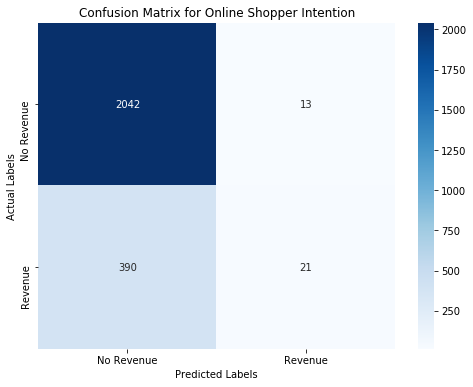

In [13]:
"""
Part 06: Visualize the Confusion Matrix

1. Import matplotlib.pyplot and seaborn here

2. Calculate the confusion matrix using the actual and the predicted values.

3. Create a heatmap using `matplotlib` and `seaborn` to visualize the confusion matrix.

4. Ensure to label the heatmap with actual labels for better readability.

NOTE: 
- Your plot cannot be autograded.  
- If you go to the guide, there will be a PDF with the solution plot.
- Please check it and if your answer matches, set the variable q6_plot_check = 'yes' .   

"""

q6_plot_check = 'no' # change to yes after you verify your plot

# YOUR CODE HERE

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 2. Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. & 4. Create the heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Revenue', 'Revenue'], 
            yticklabels=['No Revenue', 'Revenue'])

plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix for Online Shopper Intention')
plt.show()

# After verifying your plot matches the solution PDF:
q6_plot_check = 'yes'

In [14]:
##########################
### TEST YOUR SOLUTION ###
##########################

assert_equal('yes', q6_plot_check)